In [1]:
## tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

C:\Users\agarw\AppData\Local\Temp\ipykernel_22028\2294583264.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papaers")
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("Attention is all you need")

'Page: Attention Is All You Need\nSummary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the '

In [6]:
from dotenv import load_dotenv
load_dotenv(override=True)  # <-- Add override=True here

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [7]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\agarw\AppData\Local\Temp\ipykernel_22028\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [32]:
tavily.invoke("Provide me the recent AI News")

[{'title': 'The Latest AI News and Breakthroughs That Matter Most',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': "Date: May 21, 2026\n\nSummary: SoundHound AI announced the acquisition of conversational AI platform LivePerson, combining its voice and audio recognition capabilities with LivePerson's digital messaging products. Management has set 2027 revenue targets of $350 million to $400 million and identified a $500 million cross-selling opportunity across the combined customer base. The deal positions SoundHound to compete more directly with Microsoft, Google, and Amazon across enterprise contact centers, healthcare, and financial services.\n\nSource:Simply Wall St ↗\n\n### (AI News) Nvidia's Memory Costs Soar 485% as Latest AI Systems Now Cost $7.8 Million to Build\n\nDate: May 21, 2026 [...] Date: May 21, 2026\n\nSummary: The General Services Administration announced a OneGov agreement with Snowflake, making its AI and cloud-based data products

In [8]:
## combine all these tools in the list

tools = [arxiv, wiki, tavily]

In [9]:
## initialize the llm model

from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-120b")

In [10]:
llm.invoke("What is AI?")

AIMessage(content='**Artificial Intelligence (AI)** is a branch of computer science that aims to create machines and software capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity. Below is a concise overview of what AI is, how it works, and why it matters.\n\n---\n\n## 1. Core Definition\n- **AI**: The design and development of algorithms, models, and systems that can perceive their environment, process information, make decisions, and act autonomously (or semi‑autonomously) to achieve specific goals.\n\n---\n\n## 2. Main Approaches & Paradigms\n\n| Approach | Key Idea | Typical Techniques | Example Use‑Cases |\n|----------|----------|--------------------|-------------------|\n| **Symbolic / Rule‑Based AI** | Knowledge is encoded explicitly as symbols and logical rules. | Expert systems, production rules, ontologies. | Medical diagnosis expert systems, lega

In [11]:
llm_with_tools = llm.bind_tools(tools = tools)

In [12]:
### execute the call

llm_with_tools.invoke("What is machine learning?")

AIMessage(content='**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on building systems that can automatically improve their performance on a task through experience (i.e., data) rather than being explicitly programmed for every possible scenario.\n\n### Core Idea\n- **Data‑driven modeling**: An ML algorithm discovers patterns, relationships, or rules directly from data.\n- **Iterative improvement**: The model is trained on a set of examples, evaluated, and refined repeatedly until it reaches an acceptable level of accuracy or utility.\n- **Generalization**: After training, the model should make reliable predictions or decisions on new, unseen data.\n\n### Typical Workflow\n1. **Define the problem** – classification, regression, clustering, recommendation, etc.  \n2. **Collect and preprocess data** – cleaning, normalizing, feature engineering.  \n3. **Choose a model/algorithm** – linear models, decision trees, neural networks, etc.  \n4. **Train the

### Workflow

In [13]:
# state schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage      ## human message or ai message
from typing import Annotated       ## labelling
from langgraph.graph.message import add_messages    ## reducers in langgraph

In [14]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

edges: start -> ai assitant -> tools -> end
nodes: ai assitant, tools

In [15]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition  ## when a tool should be called

In [16]:
### Node definition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [17]:
# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

In [18]:
# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)

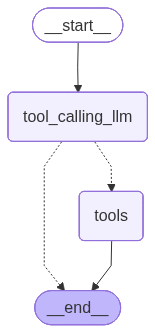

In [19]:
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
messages = graph.invoke({"messages": "1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_7762f0bc-4b96-4dee-b20c-9bf722b28cbb)
 Call ID: fc_7762f0bc-4b96-4dee-b20c-9bf722b28cbb
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [20]:
messages = graph.invoke({"messages": "Hello! I am Tarushi. How are you doing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello! I am Tarushi. How are you doing?
================================== Ai Message ==================================

Hello Tarushi! I’m doing great, thank you for asking. How can I assist you today?


In [21]:
### Node definition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

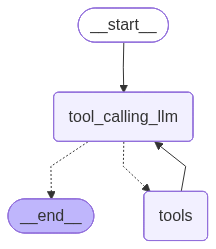

In [31]:
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
messages = graph.invoke({"messages": "Hello! I am Tarushi. How are you doing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello! I am Tarushi. How are you doing?
================================== Ai Message ==================================

Hello Tarushi! I’m doing great, thank you for asking. How can I assist you today?


In [22]:
messages = graph.invoke({"messages": "Hello! I am Tarushi. How are you doing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello! I am Tarushi. How are you doing?
================================== Ai Message ==================================

Hello, Tarushi! I'm doing great, thank you for asking. How can I assist you today?


In [23]:
messages = graph.invoke({"messages": "When was quantum computing introduced? Then, please tell me the recent research paper on quantum computing"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

When was quantum computing introduced? Then, please tell me the recent research paper on quantum computing
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_ae4852ae-98a9-407a-ac69-b5f32441b899)
 Call ID: fc_ae4852ae-98a9-407a-ac69-b5f32441b899
  Args:
    query: quantum computing sort:submittedDate desc
================================= Tool Message =================================
Name: arxiv

Published: 2022-11-04
Title: Tierkreis: A Dataflow Framework for Hybrid Quantum-Classical Computing
Authors: Seyon Sivarajah, Lukas Heidemann, Alan Lawrence, Ross Duncan
Summary: We present Tierkreis, a higher-order dataflow graph program representation and runtime designed for compositional, quantum-classical hybrid algorithms. The design of the system is motivated by the remote nature of quantum computers, the need for hybrid algorithms to involve cloud and